In [1]:
import warnings

warnings.filterwarnings("ignore")

# QuantNado — Multi-Modal Dataset Exploration

This notebook walks through a complete analysis workflow using **QuantNado**: a toolkit for
efficient Zarr-backed storage and analysis of multi-modal genomic signal.

**Workflow covered:**
1. **Setup & Data** — Install dependencies and download test data
2. **Create Dataset** — Build unified multi-modal Zarr store from BAM/bedGraph/VCF files
3. **Load & Inspect** — Open the store and view available modalities
4. **Quality Control** — PCA, sample correlations, and data completeness overview
5. **Coverage Analysis** — Reduce signal over regions, feature counts, visualization
6. **Methylation Analysis** — CpG-level methylation, distribution, metaplots, tornado plots
7. **Variant Analysis** — Genotypes, allele frequencies, region-level filtering
8. **Multi-Modal Integration** — Locus browser and cross-modality comparisons

---

## Setup

> **Dependencies**  
> Install the optional example dependencies before running this notebook:
> ```bash
> pip install "quantnado[example]"
> ```
> This adds `ipykernel` and `matplotlib` on top of the core install.

In [2]:
import re
import tarfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import quantnado as qn

## Data

The test dataset (BAM files, chr21 only) needs to be downloaded before running this notebook.
Run the cell below to fetch and extract it automatically, or manually:

```bash
# From the example/ directory
curl -L https://userweb.molbiol.ox.ac.uk/public/project/milne_group/cchahrou/quantnado/seqnado_output.tar.gz \
  | tar -xz -C multiomics_run/

```

The reference files (`reference/chr21.gtf`, `reference/promoters_1024bp.bed`) are already included in the repository.

---

In [3]:
DATA_URL = "https://userweb.molbiol.ox.ac.uk/public/project/milne_group/cchahrou/quantnado/seqnado_output.tar.gz"
REF_URL = "https://userweb.molbiol.ox.ac.uk/public/project/milne_group/cchahrou/quantnado/reference.tar.gz"
RUN_DIR = Path("multiomics_run")
RUN_DIR.mkdir(parents=True, exist_ok=True)

for url in [DATA_URL, REF_URL]:
    filename = url.split("/")[-1]
    basename = filename.split(".tar.gz")[0]
    archive_path = RUN_DIR / filename
    outdir = RUN_DIR / basename
    if not outdir.exists():
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, archive_path)
        print(f"Extracting {filename}...")
        with tarfile.open(archive_path) as tf:
            tf.extractall(RUN_DIR)
        archive_path.unlink()
        print(f"Done with {filename}.")
    else:
        print(f"{filename} already present — skipping download.")

Extracting seqnado_output.tar.gz...
Done with seqnado_output.tar.gz.
Extracting reference.tar.gz...
Done with reference.tar.gz.


In [4]:
# Paths relative to this notebook (example/)
OUT_DIR = RUN_DIR / "seqnado_output"
REF_DIR = RUN_DIR / "reference"

MS_PATH = RUN_DIR / "dataset"  # MultiomicsStore directory
BED_FILE = str(REF_DIR / "promoters_1024bp.bed")
GTF_FILE = str(REF_DIR / "chr21.gtf")
FIG_DIR = RUN_DIR / "figures"

FIG_DIR.mkdir(parents=True, exist_ok=True)

---
## Create a Unified Multi-Modal Dataset

`MultiomicsStore.from_files()` creates one directory (`dataset/`) containing a
sub-Zarr for each supplied modality:

| Sub-store | Input | What is stored |
|---|---|---|
| `coverage.zarr` | BAM files | per-base read depth (dense, sample × position) |
| `methylation.zarr` | MethylDackel bedGraph | CpG methylation % and counts (sparse) |
| `variants.zarr` | VCF.gz files | genotype, allele depths, quality (sparse) |

Run this cell once; it is skipped automatically if the store already exists.

In [ ]:
bam_files = sorted(RUN_DIR.rglob("*.bam"))
vcf_files = sorted(RUN_DIR.rglob("*.vcf.gz"))
vcf_sample_names = [re.split("_|\\.", f.stem)[0] for f in vcf_files]
meth_files = sorted(RUN_DIR.rglob("*.bedGraph"))
meth_sample_names = [re.split("_|\\.", f.stem)[0] for f in meth_files]
rna_samples  = [f for f in bam_files if "rna" in f.stem]
rna_sample_names = [re.split("_|\\.", f.stem)[0] for f in rna_samples]

if MS_PATH.exists():
    print(f"Skipping dataset construction since {MS_PATH} already exists.")
else:
    qn.create_dataset(
        store_dir=MS_PATH,
        bam_files=bam_files,
        methylation_files=meth_files,
        vcf_files=vcf_files,
        methylation_sample_names=meth_sample_names,
        vcf_sample_names=vcf_sample_names,
        filter_chromosomes=True,
        overwrite=True,
        resume=False,
        chunk_len=1048576,
        construction_compression="default",
        local_staging=False,
        staging_dir=OUT_DIR / "staging",
        log_file="dataset.log",
        max_workers=8,
        chr_workers=4,
        test=True,
        stranded=rna_sample_names,
    )

2026-03-09 15:32:43.036 | INFO     | quantnado.api:create_dataset:440 - Creating QuantNado dataset at 'multiomics_run/dataset'
  atac                      [coverage]
  chip-rx_MLL               [coverage]
  meth-rep1                 [coverage, methylation]
  meth-rep2                 [coverage, methylation]
  rna-spikein-control-rep1  [stranded_coverage]
  rna-spikein-control-rep2  [stranded_coverage]
  rna-spikein-treated-rep1  [stranded_coverage]
  rna-spikein-treated-rep2  [stranded_coverage]
  snp                       [coverage, variants]
2026-03-09 15:32:43.036 | INFO     | quantnado.dataset.store_multiomics:from_files:184 - Building coverage store from 9 BAM file(s)...
2026-03-09 15:32:43 [INFO] Extracting chromsizes from multiomics_run/seqnado_output/atac/aligned/atac.bam
2026-03-09 15:32:43 [INFO] Building dataset under staging path multiomics_run/seqnado_output/staging/.coverage.staging-0aaf71f042244503b54ad35dfd803c09.zarr before publishing to multiomics_run/dataset/coverage

---
## Load and Inspect the Dataset

In [7]:
ds = qn.open(MS_PATH)
print(ds)

2026-03-09 15:32:58 [INFO] Resuming existing store at multiomics_run/dataset/coverage.zarr
2026-03-09 15:32:58 [INFO] Resuming existing MethylStore at multiomics_run/dataset/methylation.zarr
2026-03-09 15:32:58 [INFO] Resuming existing VariantStore at multiomics_run/dataset/variants.zarr


MultiomicsStore at 'multiomics_run/dataset'
  modalities : ['coverage', 'methylation', 'variants']
  coverage    : 9 samples, 1 chrom(s)
  methylation : 2 samples, 1 chrom(s)
  variants    : 1 samples, 1 chrom(s)


In [8]:
print("Available modalities:", ds.modalities)
print("Chromosomes        :", ds.chromosomes)
print()

metadata = ds.get_metadata()
metadata

Available modalities: ['coverage', 'methylation', 'variants']
Chromosomes        : ['chr21']



,sample_hash,completed,sparsity,modalities
sample_id,,,,
atac,96ae824c5c35c004df1b9db3db07283e,True,99.904594,coverage
chip-rx_MLL,ea6b78070b8d28b7a0239eca45893bd4,True,95.253860,coverage
meth-rep1,f5ba0583afa25559ed30c9e8e2709f07,True,94.216675,"coverage, methylation"
meth-rep2,bcc7e3bf38ae81f6947662683190e221,True,93.745697,"coverage, methylation"
rna-spikein-control-rep1,2414b9280438e98f0c7cf50d5324bc2f,True,97.987144,stranded_coverage
rna-spikein-control-rep2,9b73f71b7438cdc6081be20663ee4929,True,98.167877,stranded_coverage
rna-spikein-treated-rep1,53da554c5e301439abe48b13b8838b67,True,96.408737,stranded_coverage
rna-spikein-treated-rep2,c2ac62c58d5c053b6f9400e46e08441f,True,96.751144,stranded_coverage
snp,e9eae880d15aaf4929da8db87d4dcb83,True,99.945015,"coverage, variants"


---
## Quality Control & Overview

Before diving into modality-specific analyses, let's assess data quality and get an overview of sample relationships.

### PCA on Promoter Signal

Principal component analysis reveals whether samples cluster by expected biological groupings
(e.g. assay type, treatment) and flags outliers. This is a standard QC step.

In [9]:
promoter_signal = ds.reduce(intervals_path=BED_FILE, reduction="mean")
promoter_signal

2026-03-09 15:32:58 [INFO] Chromosome compatibility check: 1 shared chromosomes out of 1 in BED/GTF file and 1 in dataset


<xarray.Dataset> Size: 356kB
Dimensions:       (ranges: 1456, sample: 9)
Coordinates:
  * ranges        (ranges) int64 12kB 0 1 2 3 4 5 ... 1451 1452 1453 1454 1455
    range_index   (ranges) int64 12kB 0 1 2 3 4 5 ... 1451 1452 1453 1454 1455
    start         (ranges) int64 12kB 5011852 5011852 ... 46635162 46635162
    end           (ranges) int64 12kB 5012876 5012876 ... 46636186 46636186
    range_length  (ranges) int64 12kB 1024 1024 1024 1024 ... 1024 1024 1024
    contig        (ranges) object 12kB 'chr21' 'chr21' ... 'chr21' 'chr21'
    strand        (ranges) object 12kB '+' '+' '+' '+' '+' ... '+' '+' '+' '+'
    name          (ranges) object 12kB 'LOC124905051:XM_047441065.1' ... 'PRM...
  * sample        (sample) <U24 864B 'atac' 'chip-rx_MLL' ... 'snp'
Data variables:
    sum           (ranges, sample) float32 52kB dask.array<chunksize=(1456, 1), meta=np.ndarray>
    count         (ranges, sample) int64 105kB dask.array<chunksize=(1456, 1), meta=np.ndarray>
    mean          (ranges, sample) float64 105kB dask.array<chunksize=(1456, 1), meta=np.ndarray>

In [10]:
pca_obj, pca_result = qn.pca(
    promoter_signal["mean"],
    n_components=8,
    nan_handling_strategy="drop",
    chromosome="chr21",
)

INFO:dask.sizeof:Selected chromosome chr21 for PCA with shape (9, 1456)
INFO:dask.sizeof:Dropped NaN-containing features


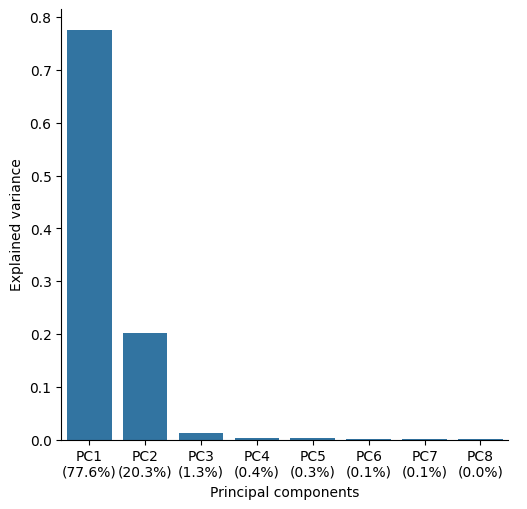

In [11]:
scree = qn.plot_pca_scree(pca_obj, filepath=FIG_DIR / "pca_scree.png")

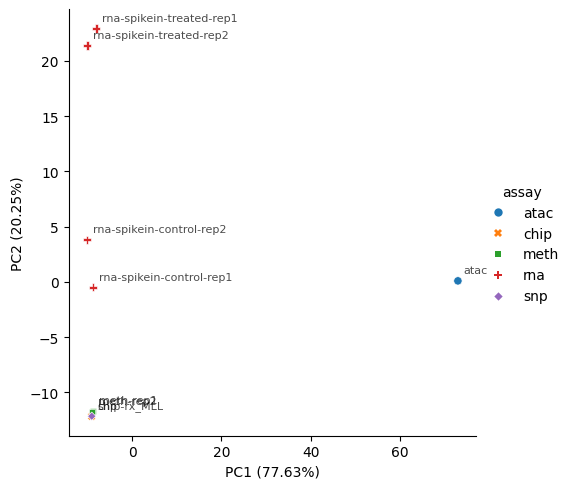

In [12]:
metadata["assay"] = metadata.index.str.split("-").str[0]

scatter = qn.plot_pca_scatter(
    pca_obj,
    pca_result,
    xaxis_pc=1,
    yaxis_pc=2,
    metadata_df=metadata,
    colour_by="assay",
    shape_by="assay",
    height=5,
    filepath=FIG_DIR / "pca_scatter_pc1_pc2.png",
)

---
## Coverage Analysis

### Reduce Signal over Genomic Regions

Aggregate per-base signal across genomic intervals (e.g. promoters, peaks) to produce a
compact `(regions × samples)` matrix. Useful for downstream analysis such as PCA and clustering.

Reduction methods: `mean`, `sum`, `max`, `min`, `median`.

### Clustered Heatmap of Promoter Signal

`qn.heatmap()` takes the output of `reduce()` and plots a seaborn clustermap with hierarchical
clustering on both rows (features) and columns (samples).

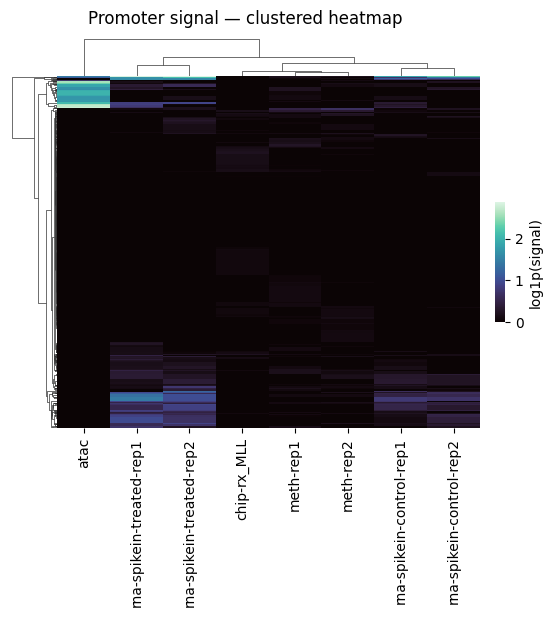

In [13]:
g = qn.heatmap(
    promoter_signal,
    variable="mean",
    log_transform=True,
    cmap="mako",
    figsize=(5, 6),
    title="Promoter signal — clustered heatmap",
    filepath=FIG_DIR / "promoter_clustermap.png",
)
plt.show()

### Sample–Sample Correlation

`qn.correlate()` computes Pearson (or Spearman) correlations between all sample pairs and plots
the result as a clustered heatmap. Returns the correlation `pd.DataFrame` alongside the figure.

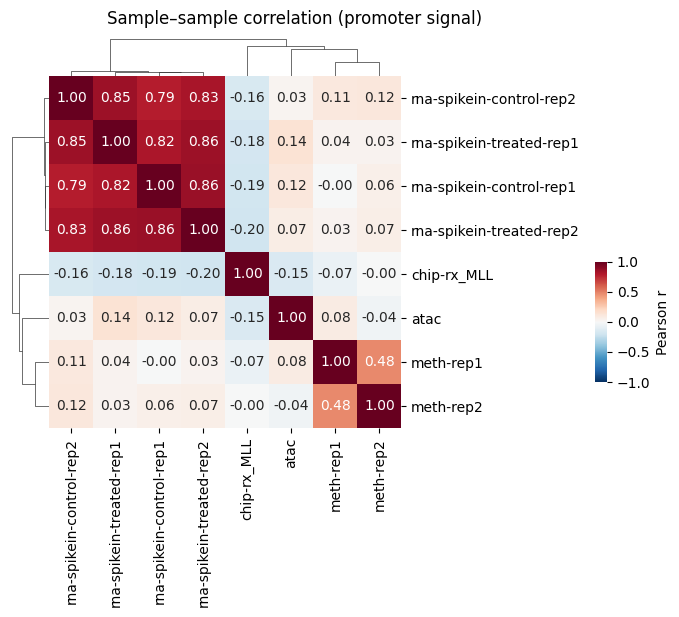

In [14]:
corr_df, g = qn.correlate(
    promoter_signal,
    variable="mean",
    log_transform=True,
    annotate=True,
    cmap="RdBu_r",
    figsize=(6, 6),
    title="Sample–sample correlation (promoter signal)",
    filepath=FIG_DIR / "sample_correlation.png",
)
plt.show()

### Feature Count Matrix (DESeq2-compatible)

Sum signal across gene bodies to produce an integer count matrix ready for differential
expression analysis in DESeq2 or edgeR.

In [15]:
ds.coverage

In [16]:
counts, features = ds.count_features(
    samples=rna_sample_names,
    gtf_file=GTF_FILE,
    feature_type="transcript",
    feature_id_col=["gene_id", "transcript_id"],
    integerize=True,
    strand=2,
)

print(f"Count matrix: {counts.shape[0]} genes × {counts.shape[1]} samples")
print(f"Feature metadata: {features.shape[0]} features × {features.shape[1]} columns")

2026-03-09 15:33:10 [INFO] Chromosome compatibility check: 1 shared chromosomes out of 1 in input ranges and 1 in dataset


Count matrix: 986 genes × 4 samples
Feature metadata: 986 features × 7 columns


In [17]:
counts.loc["RUNX1"]

,rna-spikein-control-rep1,rna-spikein-control-rep2,rna-spikein-treated-rep1,rna-spikein-treated-rep2
transcript_id,,,,
NM_001122607.2,98,0,260,203
NM_001001890.3,177,42,316,310
NM_001754.5,931,270,1077,2165


In [18]:
features.loc["RUNX1"]

,gene_id,transcript_id,contig,strand,start,end,range_length
transcript_id,,,,,,,
NM_001122607.2,RUNX1,NM_001122607.2,chr21,-,36193575,36260996,67421
NM_001001890.3,RUNX1,NM_001001890.3,chr21,-,36160097,36260996,100899
NM_001754.5,RUNX1,NM_001754.5,chr21,-,36160097,36421599,261502


In [19]:
counts_path = OUT_DIR / "counts_matrix.csv"
counts.to_csv(counts_path)
print(f"Counts saved to {counts_path}")

Counts saved to multiomics_run/seqnado_output/counts_matrix.csv


### Extract Raw Signal over Regions

`qn.extract()` returns the full per-position signal for each genomic interval as a
`(intervals × positions × samples)` DataArray — useful for metagene plots, coverage
tracks, and deep-learning feature engineering.

Setting `fixed_width` centres all intervals to the same length; `bin_size` downsamples
positions into coarser bins.

In [20]:
binned = ds.extract(
    modality="coverage",
    feature_type="transcript",
    gtf_path=GTF_FILE,
    upstream=1000,
    downstream=1000,
    anchor="start",
    bin_size=50,
)

binned

2026-03-09 15:33:12 [INFO] Chromosome compatibility check: 1 shared chromosomes out of 1 in GTF and 3 in dataset


<xarray.DataArray 'getitem-14d3d3e9ea3e0346a36143f35918eb1e' (interval: 986,
                                                              bin: 40, sample: 9)> Size: 1MB
dask.array<getitem, shape=(986, 40, 9), dtype=float32, chunksize=(518, 40, 1), chunktype=numpy.ndarray>
Coordinates:
  * interval  (interval) int64 8kB 0 1 2 3 4 5 6 ... 979 980 981 982 983 984 985
    start     (interval) int64 8kB 46707966 46683849 ... 9733506 9689972
    end       (interval) int64 8kB 46717269 46707810 ... 9734109 9690726
    contig    (interval) <U5 20kB 'chr21' 'chr21' 'chr21' ... 'chr21' 'chr21'
    strand    (interval) object 8kB '+' '-' '-' '-' '-' ... '+' '+' '+' '+' '-'
  * bin       (bin) int64 320B -1000 -950 -900 -850 -800 ... 750 800 850 900 950
  * sample    (sample) <U24 864B 'atac' 'chip-rx_MLL' ... 'snp'
Attributes:
    upstream:    1000
    downstream:  1000
    anchor:      start
    bin_size:    50
    bin_agg:     mean

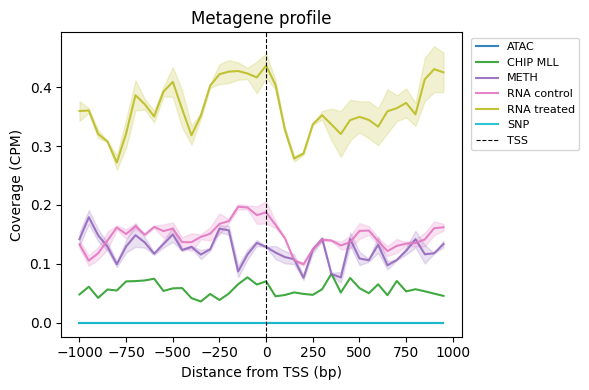

In [21]:
metadata["assay"] = metadata.index.to_series().apply(lambda s: s.split("-")[0])
metadata["condition"] = [
    "control" if "control" in s else "treated" if "treated" in s else "" for s in metadata.index
]
metadata["group"] = metadata["assay"].str.upper()
metadata.loc[metadata["assay"] == "rna", "group"] += " " + metadata["condition"]
metadata.loc[metadata["assay"] == "chip", "group"] += " MLL"
groups_dict = metadata.groupby("group").groups

ax = ds.metaplot(
    binned,
    modality="coverage",
    groups=groups_dict,
    flip_minus_strand=True,
    error_stat="sem",
    palette="tab10",
    reference_point=0,
    reference_label="TSS",
    xlabel="Distance from TSS (bp)",
    title="Metagene profile",
    figsize=(6, 4),
    filepath=FIG_DIR / "metaplot.png",
)


#### Tornado plot (signal heatmap over TSSs)

Each row is one genomic interval (TSS ± window), colour encodes signal intensity.  
Intervals are sorted by mean signal of the first panel so all panels share the same row order.

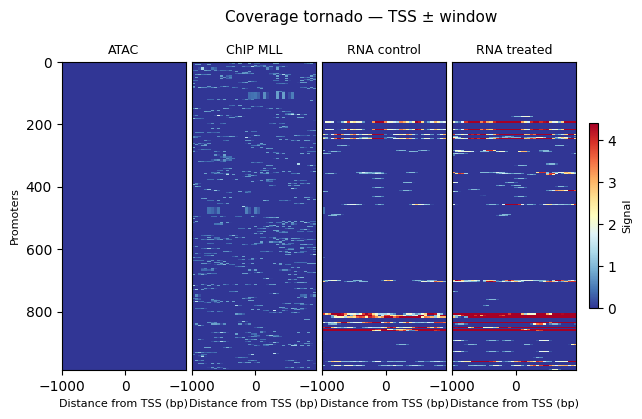

In [22]:
axes = ds.tornadoplot(
    binned,
    modality="coverage",
    samples=["atac", "chip-rx_MLL", "rna-spikein-control-rep1", "rna-spikein-treated-rep1"],
    sample_names=["ATAC", "ChIP MLL", "RNA control", "RNA treated"],
    flip_minus_strand=True,
    sort_by="mean",
    reference_point=None,
    reference_label="TSS",
    xlabel="Distance from TSS (bp)",
    ylabel="Promoters",
    title="Coverage tornado — TSS ± window",
    figsize=(8, 4),
    filepath=FIG_DIR / "tornado_tss.png",
)

### CPM-normalised tornado plot

Normalise the per-position signal to **CPM** (Counts Per Million mapped reads) before
plotting so that tracks are comparable across samples with different sequencing depths.

> **Note:** CPM is the correct normalisation for signal tracks from `extract()`.  
> RPKM / TPM apply to summarised feature counts (output of `count_features()`), not
> per-position or binned signal.

2026-03-09 15:33:14 [INFO] Chromosome compatibility check: 1 shared chromosomes out of 1 in GTF and 3 in dataset
2026-03-09 15:33:14 [INFO] Normalised xr.DataArray to CPM.


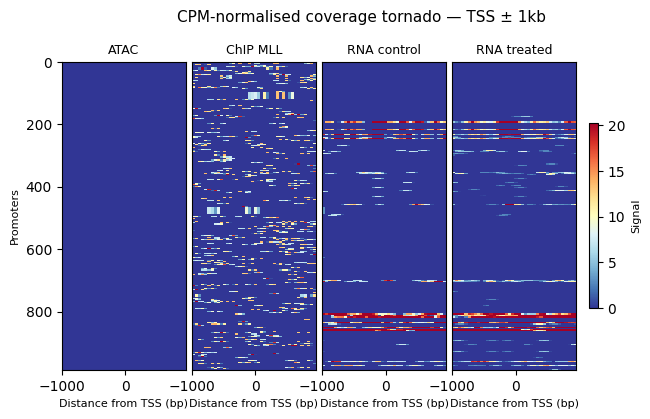

In [23]:
library_sizes = qn.get_library_sizes(ds)

# Extract binned signal (reuse params from the raw tornado above)
binned_cpm_input = ds.extract(
    modality="coverage",
    feature_type="transcript",
    gtf_path=GTF_FILE,
    upstream=1000,
    downstream=1000,
    anchor="start",
    bin_size=50,
)

# Normalise to cpm
cpm_binned = ds.normalise(binned_cpm_input, method="cpm", library_sizes=library_sizes)

axes = ds.tornadoplot(
    cpm_binned,
    modality="coverage",
    samples=["atac", "chip-rx_MLL", "rna-spikein-control-rep1", "rna-spikein-treated-rep1"],
    sample_names=["ATAC", "ChIP MLL", "RNA control", "RNA treated"],
    flip_minus_strand=True,
    sort_by="mean",
    reference_point=None,
    reference_label="TSS",
    xlabel="Distance from TSS (bp)",
    ylabel="Promoters",
    title="CPM-normalised coverage tornado — TSS ± 1kb",
    figsize=(8, 4),
    filepath=FIG_DIR / "tornado_tss_cpm.png",
)

#### Stranded RNA-seq visualization

For samples built with `stranded=rna_sample_names`, `_fwd` and `_rev` arrays are stored
separately.  Extract forward- and reverse-strand signal independently with `strand="+"` /
`strand="-"` and pass both to `metaplot` / `tornadoplot` via the `data_rev` parameter.

- **`metaplot`**: sense profile above zero; antisense profile mirrored below  
- **`tornadoplot`**: heatmap of `fwd − rev` per interval (divergent colormap)

2026-03-09 15:33:15 [INFO] Chromosome compatibility check: 1 shared chromosomes out of 1 in GTF and 3 in dataset
2026-03-09 15:33:15 [INFO] Chromosome compatibility check: 1 shared chromosomes out of 1 in GTF and 3 in dataset


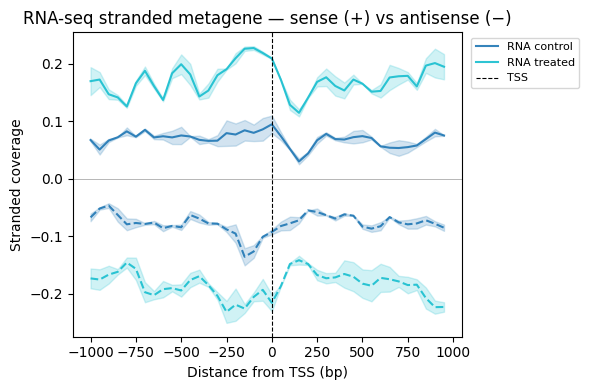

In [24]:
rna_groups = {k: v for k, v in groups_dict.items() if "RNA" in k}

binned_rna_fwd = ds.extract(
    modality="coverage",
    feature_type="transcript",
    gtf_path=GTF_FILE,
    upstream=1000,
    downstream=1000,
    anchor="start",
    bin_size=50,
    samples=rna_sample_names,
    strand="+",
)

binned_rna_rev = ds.extract(
    modality="coverage",
    feature_type="transcript",
    gtf_path=GTF_FILE,
    upstream=1000,
    downstream=1000,
    anchor="start",
    bin_size=50,
    samples=rna_sample_names,
    strand="-",
)

ax = ds.metaplot(
    binned_rna_fwd,
    data_rev=binned_rna_rev,
    modality="coverage",
    groups=rna_groups,
    flip_minus_strand=True,
    error_stat="sem",
    palette="tab10",
    reference_point=0,
    reference_label="TSS",
    xlabel="Distance from TSS (bp)",
    ylabel="Stranded coverage",
    title="RNA-seq stranded metagene — sense (+) vs antisense (−)",
    figsize=(6, 4),
    filepath=FIG_DIR / "metaplot_rna_stranded.png",
)

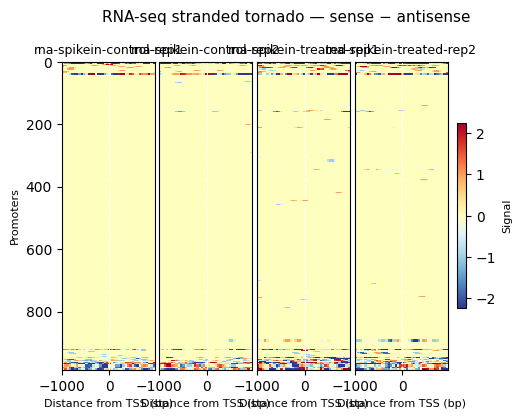

In [25]:
axes = ds.tornadoplot(
    binned_rna_fwd,
    data_rev=binned_rna_rev,
    modality="coverage",
    samples=rna_sample_names,
    flip_minus_strand=True,
    sort_by="mean",
    reference_point=0,
    reference_label="TSS",
    xlabel="Distance from TSS (bp)",
    ylabel="Promoters",
    title="RNA-seq stranded tornado — sense − antisense",
    figsize=(6, 4),
    filepath=FIG_DIR / "tornado_rna_stranded.png",
)

#### Extract Signal for a Single Genomic Region

Use `extract_region` to pull the raw per-base coverage for any genomic locus across all samples.

In [26]:
REGION="chr21:36193575-36260996"

region = ds.extract_region(REGION)
print(f"Region shape: {region.shape}  (samples × positions)")

2026-03-09 15:33:17 [INFO] Extracted region chr21:36193575-36260996 (67421 bp) for 9 sample(s)


Region shape: (9, 67421)  (samples × positions)


2026-03-09 15:33:17 [INFO] Extracted region chr21:36193575-36260996 (67421 bp) for 9 sample(s)
2026-03-09 15:33:17 [INFO] Extracted region chr21:36193575-36260996 (67421 bp) for 9 sample(s)
2026-03-09 15:33:17 [INFO] Extracted region chr21:36193575-36260996 (67421 bp) for 9 sample(s)


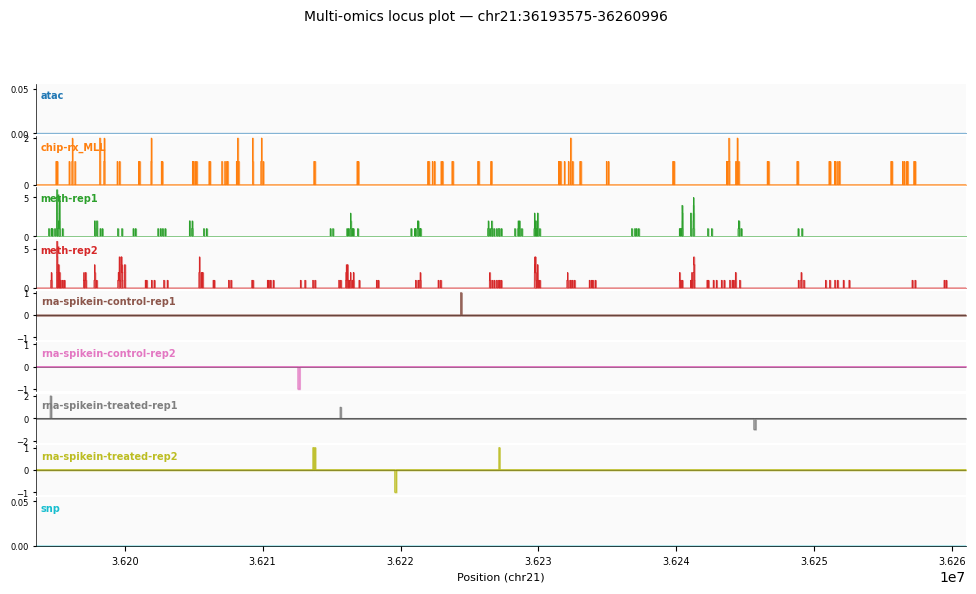

In [27]:
plt = ds.locus_plot(
    locus=REGION,
    sample_names=ds.samples,
    modality=[
        "stranded_coverage" if s in rna_sample_names else "coverage"
        for s in ds.samples
    ],
    palette="tab10",
    title=f"Multi-omics locus plot — {REGION}",
    figsize=(12, 6),
    filepath=FIG_DIR / "locus_plot.png",
)

#### Stranded RNA-seq locus plot

For stranded samples, pass `modality="stranded_coverage"` — forward and reverse coverage
are fetched automatically and plotted mirrored around zero (forward above, reverse below).

2026-03-09 15:33:19 [INFO] Extracted region chr21:36193575-36260996 (67421 bp) for 9 sample(s)
2026-03-09 15:33:19 [INFO] Extracted region chr21:36193575-36260996 (67421 bp) for 9 sample(s)


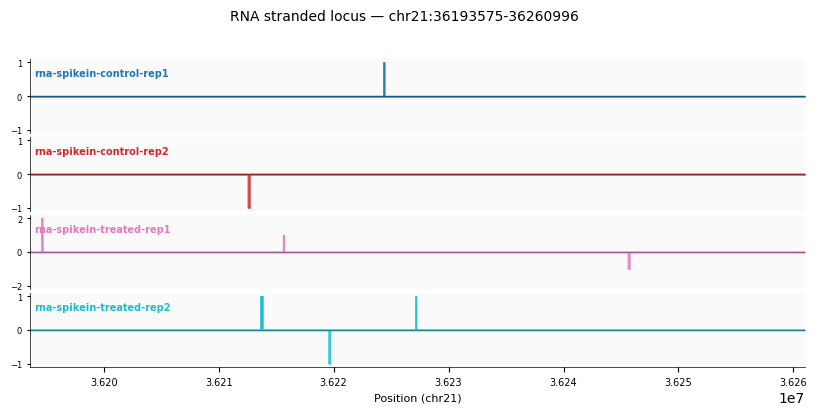

In [28]:
plt = ds.locus_plot(
    locus=REGION,
    sample_names=rna_sample_names,
    modality=["stranded_coverage"] * len(rna_sample_names),
    palette="tab10",
    title=f"RNA stranded locus — {REGION}",
    figsize=(10, 4),
    filepath=FIG_DIR / "locus_plot_rna_stranded.png",
)

---
## Methylation Analysis

`ms.methylation` is a `MethylStore` — a sparse Zarr store where each chromosome has:
- `positions` — the union of CpG start coordinates (0-based) across all samples
- `methylation_pct` — methylation percentage per site per sample (`NaN` = not covered)
- `n_methylated` / `n_unmethylated` — read counts

In [29]:
meth = ds.methylation
print(f"Samples : {meth.sample_names}")
for chrom in meth.chromosomes:
    print(f"  {chrom}: {len(meth.get_positions(chrom)):,} CpG sites")

meth_xr = meth.to_xarray(variable="methylation_pct")
print()
print(meth_xr["chr21"])

Samples : ['meth-rep1', 'meth-rep2']
  chr21: 19,751 CpG sites

<xarray.DataArray 'array-b15e15809889fe3f377a3543844cf5ce' (sample: 2,
                                                            position: 19751)> Size: 158kB
dask.array<array, shape=(2, 19751), dtype=float32, chunksize=(1, 19751), chunktype=numpy.ndarray>
Coordinates:
  * sample     (sample) <U9 72B 'meth-rep1' 'meth-rep2'
    completed  (sample) bool 2B True True
  * position   (position) int64 158kB 5067013 5067171 ... 46698163 46698204
Attributes:
    variable:    methylation_pct
    chromosome:  chr21


### Methylation distribution

### Extract methylation over a specific region

In [30]:
stats, features = ds.methylation.count_features(
    gtf_file=GTF_FILE,
    feature_type="transcript",
    feature_id_col=["gene_id", "transcript_id"],
    integerize=True,
)

print(f"Available stats: {list(stats.keys())}")
print(f"Features: {features.shape}")

stats.keys()

Available stats: ['n_methylated', 'n_unmethylated', 'n_cpg_covered', 'methylation_ratio', 'methylation_pct']
Features: (1087, 8)


dict_keys(['n_methylated', 'n_unmethylated', 'n_cpg_covered', 'methylation_ratio', 'methylation_pct'])

### Methylation Feature Counts

Similar to coverage feature counting, you can aggregate methylation statistics over genomic features.

In [31]:
region_meth = meth.extract_region(REGION, variable="methylation_pct")
print(f"Shape: {region_meth.shape}  (samples × CpG sites in RUNX1)")
print(f"CpG positions covered: {(~np.isnan(region_meth.values)).sum(axis=1)}")

Shape: (2, 51)  (samples × CpG sites in RUNX1)
CpG positions covered: [13 38]


### Methylation metaplot over promoters

For each 1024 bp promoter window on chr21, CpG sites are assigned to one of 32 bins
relative to the TSS (position 0). Minus-strand promoters are strand-corrected so that
the TSS is always at the centre. The profile shows mean methylation % per bin across all
promoters.

### Methylation Signal Visualization

Extract methylation % over genomic intervals and visualize as metaplots and tornado plots,
similar to the coverage visualizations above.

In [32]:
binned_meth = ds.extract(
    modality="methylation",
    feature_type="transcript",
    gtf_path=GTF_FILE,
    upstream=1000,
    downstream=1000,
    anchor="start",
    bin_size=50,
)

2026-03-09 15:33:20 [INFO] Chromosome compatibility check: 1 shared chromosomes out of 1 in intervals and 1 in dataset


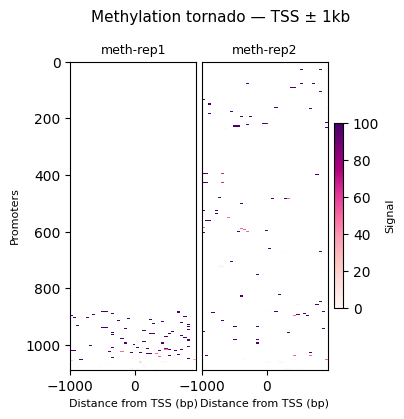

In [33]:
axes = ds.tornadoplot(
    binned_meth,
    modality="methylation",
    flip_minus_strand=True,
    sort_by="mean",
    reference_point=0,
    reference_label="TSS",
    xlabel="Distance from TSS (bp)",
    ylabel="Promoters",
    title="Methylation tornado — TSS ± 1kb",
    figsize=(4, 4),
    filepath=FIG_DIR / "tornado_tss_methylation.png",
)

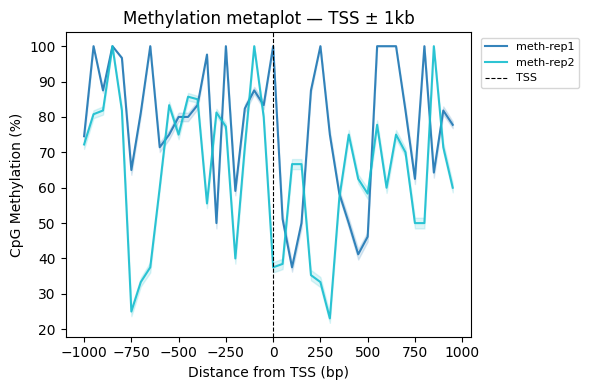

In [34]:
ax = ds.metaplot(
    binned_meth,
    modality="methylation",
    flip_minus_strand=True,
    error_stat="sem",
    palette="tab10",
    reference_point=0,
    reference_label="TSS",
    xlabel="Distance from TSS (bp)",
    ylabel="CpG Methylation (%)",
    title="Methylation metaplot — TSS ± 1kb",
    figsize=(6, 4),
    filepath=FIG_DIR / "metaplot_methylation.png",
)

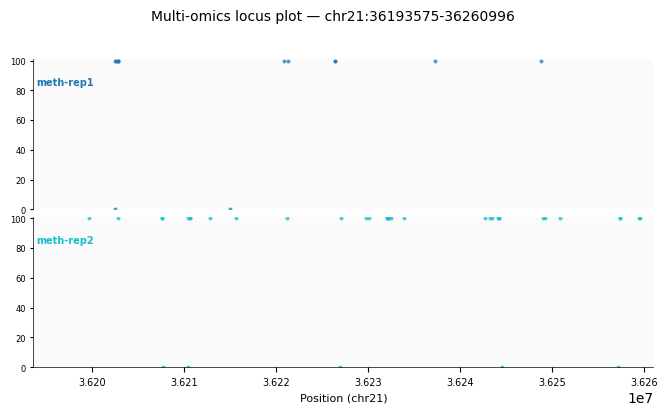

In [35]:
plt = ds.locus_plot(
    locus=REGION,
    sample_names=["meth-rep1", "meth-rep2"],
    modality=["methylation"] * 2,
    palette="tab10",
    title=f"Multi-omics locus plot — {REGION}",
    figsize=(8, 4),
    filepath=FIG_DIR / "locus_plot_methylation.png",
)

---
## Variant Analysis

`msstore_variants` is a `VariantStore` — a sparse Zarr store where each chromosome has:
- `positions` — 1-based variant positions (union across all samples)
- `genotype` — integer encoded: `-1` missing, `0` hom-ref, `1` het, `2` hom-alt
- `allele_depth_ref` / `allele_depth_alt` — read depths per allele
- `qual` — per-sample variant quality score

In [36]:
var = ds.variants
print(f"Samples : {var.sample_names}")
for chrom in var.chromosomes:
    print(f"  {chrom}: {len(var.get_positions(chrom)):,} variant sites")

gt_xr = var.to_xarray(variable="genotype")
print()
print(gt_xr["chr21"])

Samples : ['snp']
  chr21: 148 variant sites

<xarray.DataArray 'array-6a9234c7c1ce7dcac3dfa9cbb9895f17' (sample: 1,
                                                            position: 148)> Size: 148B
dask.array<array, shape=(1, 148), dtype=int8, chunksize=(1, 148), chunktype=numpy.ndarray>
Coordinates:
  * sample     (sample) <U3 12B 'snp'
    completed  (sample) bool 1B True
  * position   (position) int64 1kB 5230802 5230815 ... 13918697 13950515
Attributes:
    variable:    genotype
    chromosome:  chr21


### Genotype summary

In [37]:
gt_data = gt_xr["chr21"].compute()

labels = {-1: "missing", 0: "hom-ref", 1: "het", 2: "hom-alt"}
print("Genotype counts per sample:")
for sample in var.sample_names:
    gt = gt_data.sel(sample=sample).values
    counts = {labels[k]: int((gt == k).sum()) for k in [-1, 0, 1, 2]}
    print(f"  {sample}: {counts}")

Genotype counts per sample:
  snp: {'missing': 0, 'hom-ref': 0, 'het': 125, 'hom-alt': 23}


### Variants in a specific region

Plotting 0 variants in chr21:36193575-36260996


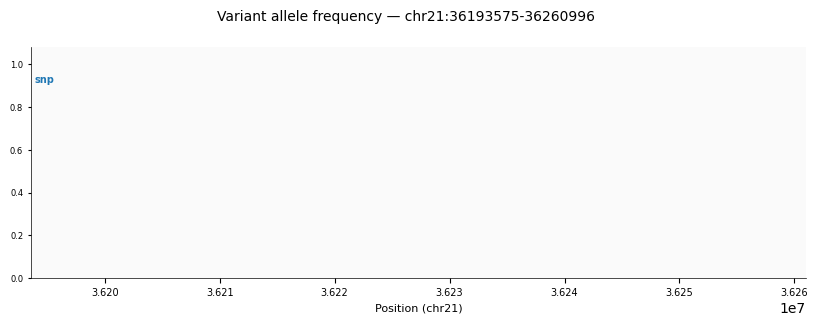

In [38]:

gt_region = var.extract_region(REGION, variable="genotype")
adr_region = var.extract_region(REGION, variable="allele_depth_ref")
ada_region = var.extract_region(REGION, variable="allele_depth_alt")

print(f"Plotting {gt_region.shape[1]} variants in {REGION}")

plt = ds.locus_plot(
    locus=REGION,
    genotype=gt_region,
    allele_depth_ref=adr_region,
    allele_depth_alt=ada_region,
    sample_names=["snp"],
    modality=["variant"],
    title=f"Variant allele frequency — {REGION}",
    figsize=(10, 3),
    filepath=FIG_DIR / "locus_plot_variants.png",
)

---
## Multi-Modal Integration

### Multi-Modal Locus Browser

View all three modalities together for a single genomic region — the same layout as a genome
browser, built directly from the `MultiomicsStore` in a few lines.

Panels (top → bottom, all sharing the same x-axis):
- **Coverage** tracks for selected assay types (ATAC, ChIP, methylation, SNP)
- **Methylation %** at individual CpG sites (one dot per site, per replicate)
- **Variant allele frequency** coloured by genotype (blue = het, red = hom-alt)

2026-03-09 15:33:21 [INFO] Extracted region chr21:36193575-36260996 (67421 bp) for 9 sample(s)
2026-03-09 15:33:21 [INFO] Extracted region chr21:36193575-36260996 (67421 bp) for 9 sample(s)
2026-03-09 15:33:21 [INFO] Extracted region chr21:36193575-36260996 (67421 bp) for 9 sample(s)


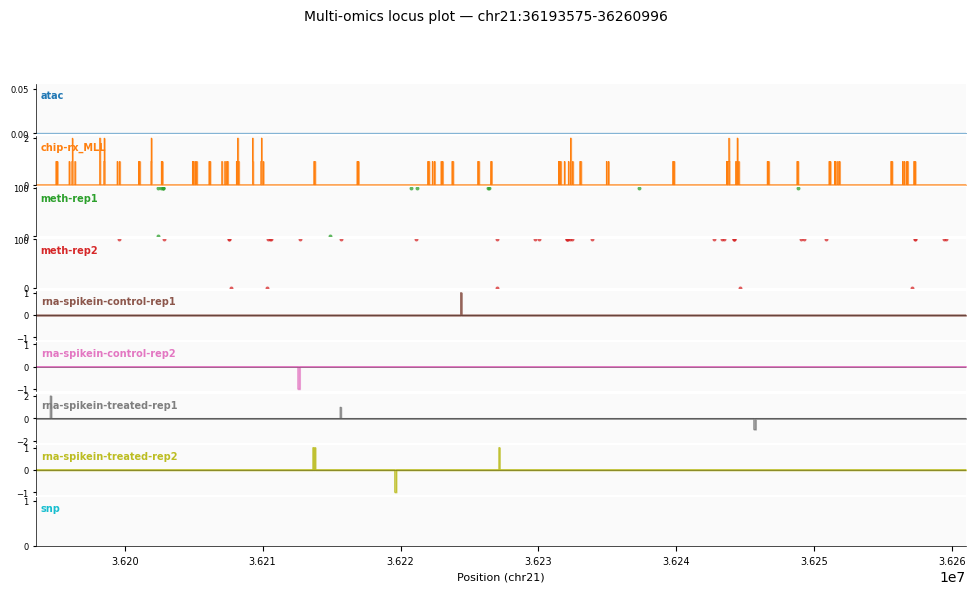

In [39]:
gt = ds.variants.extract_region(REGION, variable="genotype").compute()
adr = ds.variants.extract_region(REGION, variable="allele_depth_ref").compute()
ada = ds.variants.extract_region(REGION, variable="allele_depth_alt").compute()

plt = ds.locus_plot(
    locus=REGION,
    genotype=gt,
    allele_depth_ref=adr,
    allele_depth_alt=ada,
    sample_names=ds.samples,
    modality=[
        "methylation" if "meth" in s
        else "variant" if "snp" in s
        else "stranded_coverage" if s in rna_sample_names
        else "coverage"
        for s in ds.samples
    ],
    palette="tab10",
    title=f"Multi-omics locus plot — {REGION}",
    figsize=(12, 6),
    filepath=FIG_DIR / "locus_plot.png",
)